# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [3]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [5]:
# mostrar las primeras 5 filas de plans
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [6]:
# mostrar las primeras 5 filas de users
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [7]:
# mostrar las primeras 5 filas de usage
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [8]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [9]:
# inspección de plans con .info()
print("plans", plans.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes
plans None


In [10]:
# inspección de users con .info()
print("users", users.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB
users None


In [11]:
# inspección de usage con .info()
print("usage", usage.info()) 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB
usage None


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [12]:
# cantidad de nulos para users

cols_users= ['user_id','first_name','last_name', 'age','city','reg_date','plan','churn_date']

for col in cols_users:
    print(col,'valores nulos:', users[col].isna().sum())
print()
# Proporción de valores nulos)
for col in cols_users:
    print(col,'proporción nulos:', users[col].isna().mean())

  

user_id valores nulos: 0
first_name valores nulos: 0
last_name valores nulos: 0
age valores nulos: 0
city valores nulos: 469
reg_date valores nulos: 0
plan valores nulos: 0
churn_date valores nulos: 3534

user_id proporción nulos: 0.0
first_name proporción nulos: 0.0
last_name proporción nulos: 0.0
age proporción nulos: 0.0
city proporción nulos: 0.11725
reg_date proporción nulos: 0.0
plan proporción nulos: 0.0
churn_date proporción nulos: 0.8835


In [13]:
# cantidad de nulos para usage
cols_usage= ['id','user_id','type','date','duration','length']

for col in cols_usage:
    print(col,'valores nulos:', usage[col].isna().sum())
print()

# Proporción de valores nulos
for col in cols_usage:
    print(col,'proporción nulos:', usage[col].isna().mean())

id valores nulos: 0
user_id valores nulos: 0
type valores nulos: 0
date valores nulos: 50
duration valores nulos: 22076
length valores nulos: 17896

id proporción nulos: 0.0
user_id proporción nulos: 0.0
type proporción nulos: 0.0
date proporción nulos: 0.00125
duration proporción nulos: 0.5519
length proporción nulos: 0.4474


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
- Indica qué harías: ¿imputar, eliminar, ignorar?
- En el dataset 'users' se observan dos columnas con datos nulos: city (469, 0.11 %) y churn_date (3534, 0.88 %). Para el caso de city se puede trabajar con los datos nulos e ignoramos la columna churn_date por ausencia de datos.
- En el dataset 'usage' se observan tres columnas con datos nulos: date (50, 0.001 %), duration (22076, 0.55 %) y length (17896, 0.44 %). Se pueden trabajar con los datos nulos de la columna date y dejar como nulos duration y length.


### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [14]:
# explorar columnas numéricas de users
for col in cols_users:
    print(col,'resumen estadístico') 
    print(users[col].describe())


user_id resumen estadístico
count     4000.000000
mean     11999.500000
std       1154.844867
min      10000.000000
25%      10999.750000
50%      11999.500000
75%      12999.250000
max      13999.000000
Name: user_id, dtype: float64
first_name resumen estadístico
count      4000
unique        6
top       Mateo
freq        685
Name: first_name, dtype: object
last_name resumen estadístico
count      4000
unique        5
top       Lopez
freq        835
Name: last_name, dtype: object
age resumen estadístico
count    4000.000000
mean       33.739750
std       123.232257
min      -999.000000
25%        32.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64
city resumen estadístico
count       3531
unique         7
top       Bogotá
freq         808
Name: city, dtype: object
reg_date resumen estadístico
count                              4000
unique                             3961
top       2026-05-10 00:00:00.000000000
freq                        

- Se hallaron valores a revisar e imputar de acuerdo al caso en:
city, ?: se puede imputar con NA.
age, min -999.000000: imputar con la mediana.
reg_date, top  2026-05-10 00:00:00.000000000: se puede imputar con NA.
churn_date , top  1,71763E+18, omitir columna por ausencia de datos 88 %.


In [15]:
# explorar columnas numéricas de usage
for col in cols_usage:
    print(col,'resumen estadístico')
    print (usage[col].describe())


id resumen estadístico
count    40000.00000
mean     20000.50000
std      11547.14972
min          1.00000
25%      10000.75000
50%      20000.50000
75%      30000.25000
max      40000.00000
Name: id, dtype: float64
user_id resumen estadístico
count    40000.000000
mean     12002.405975
std       1157.279564
min      10000.000000
25%      10996.000000
50%      12013.000000
75%      13005.000000
max      13999.000000
Name: user_id, dtype: float64
type resumen estadístico
count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object
date resumen estadístico
count                             39950
unique                            39950
top       2024-02-11 21:59:13.018825470
freq                                  1
Name: date, dtype: object
duration resumen estadístico
count    17924.000000
mean         5.202237
std          6.842701
min          0.000000
25%          1.437500
50%          3.500000
75%          6.990000
max        120.000000
Name: duration, dty

- Solo revisar si son reales los valores minimos o dependen de alguna variable.
duration, min  0.000000
length, min  0.000000

In [16]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']

for col in columnas_user:
    print(col)
    print("Frecuencia absoluta")
    print(users[col].value_counts())
    print("Frecuencia relativa")
    print(users[col].value_counts(normalize=True))
    print() 


city
Frecuencia absoluta
Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64
Frecuencia relativa
Bogotá      0.228830
CDMX        0.206740
Medellín    0.174455
GDL         0.127443
Cali        0.120079
MTY         0.115265
?           0.027188
Name: city, dtype: float64

plan
Frecuencia absoluta
Basico     2595
Premium    1405
Name: plan, dtype: int64
Frecuencia relativa
Basico     0.64875
Premium    0.35125
Name: plan, dtype: float64



- La columna `city` tiene 96 sentinels tipo ?
- La columna `plan` no tiene problemas

In [17]:
# explorar columna categórica de usage

print('Frecuencia absoluta') 
print(usage['type'].value_counts())
print()
print('Frecuencia relativa')
print(usage['type'].value_counts(normalize=True))


Frecuencia absoluta
text    22092
call    17908
Name: type, dtype: int64

Frecuencia relativa
text    0.5523
call    0.4477
Name: type, dtype: float64


- La columna `type` no presenta valores invalidos.

---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?
- Se hallaron valores a revisar e imputar de acuerdo al caso en: age, min -999.000000.
- Fechas a corregir en las columnas: reg_date, top 2026-05-10 00:00:00.000000000 churn_date , top 1,71763E+18
- La columna city tiene 96 sentinels tipo ?



### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [18]:

# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')
print(users['reg_date'].dtypes)


datetime64[ns]


In [19]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')
print(usage['date'].dtypes)

datetime64[ns]


In [20]:

# Revisar los años presentes en `reg_date` de users

users['reg_date'] = users['reg_date'].dt.year
print(users['reg_date'])
print(sorted(users['reg_date'].dropna().unique()))



0       2022
1       2022
2       2022
3       2022
4       2022
        ... 
3995    2024
3996    2024
3997    2024
3998    2024
3999    2024
Name: reg_date, Length: 4000, dtype: int64
[2022, 2023, 2024, 2026]


En `reg_date` se encuentra el año 2026,  y el análisis abarca hasta el 2024.

In [21]:
# Revisar los años presentes en `date` de usage
usage['date'] = usage['date'].dt.year
print(usage['date'])
print(sorted(usage['date'].dropna().unique()))


0        2024.0
1        2024.0
2        2024.0
3        2024.0
4        2024.0
          ...  
39995    2024.0
39996    2024.0
39997    2024.0
39998    2024.0
39999    2024.0
Name: date, Length: 40000, dtype: float64
[2024.0]


En `date`, solo aparece registrado el año 2024, OK.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?
- De manera general los fechas se hallan congruentes, usage['date'] tiene registros de 2024 y en user[reg_date] se encuentra el año 2026, podemos imputar con NA.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [22]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [23]:

# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
users['city'].describe()


count       3435
unique         6
top       Bogotá
freq         808
Name: city, dtype: object

In [24]:
# Marcar fechas futuras como NA para reg_date
users['reg_date'] = users['reg_date'].replace(2026, pd.NA)

# Verificar cambios
users['reg_date'].describe()


count     3960
unique       3
top       2024
freq      1330
Name: reg_date, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [25]:
# Verificación MAR en usage (Missing At Random) para duration
usage['duration'].isna().groupby(usage['type']).mean().sort_values(ascending=False)


type
text    0.999276
call    0.000000
Name: duration, dtype: float64

In [26]:
# Verificación MAR en usage (Missing At Random) para length
usage['length'].isna().groupby(usage['type']).mean().sort_values(ascending=False)

type
call    0.99933
text    0.00000
Name: length, dtype: float64

Se observa que las columnas `duration` y `length` dependen de la columna type: en duration el 0.99 se halla en texto y 0.0 en call: asi pues, en lenght 0.99 en call, por ello, los datos se quedan como nulos, ya que son correctos.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [27]:

# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas
usage["call_mins"] = usage["duration"].where(usage["type"] == "call", 0) #total de minutos de llamadas

# Agrupar información por usuario
usage_agg = (
    usage.groupby("user_id")
         .agg({
             "is_text": "sum",
             "is_call": "sum",
             "call_mins": "sum"
         })
         .reset_index()
)

# observar resultado
usage_agg.head(3)


,user_id,is_text,is_call,call_mins
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [28]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    "is_text": "cant_mensajes",
    "is_call": "cant_llamadas",
    "call_mins": "cant_minutos_llamada"
})

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [29]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(
    usage_agg,
    on='user_id',
    how='left'
)
user_profile.head(5)


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [30]:
# Resumen estadístico de las columnas numéricas
# explorar columnas numéricas de users

cols_profile= ['user_id', 'age','city','reg_date','cant_mensajes', 'cant_llamadas','cant_minutos_llamada']

for col in cols_profile:
    print(col,'resumen estadístico') 
    print(user_profile[col].describe())



user_id resumen estadístico
count     4000.000000
mean     11999.500000
std       1154.844867
min      10000.000000
25%      10999.750000
50%      11999.500000
75%      12999.250000
max      13999.000000
Name: user_id, dtype: float64
age resumen estadístico
count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64
city resumen estadístico
count       3435
unique         6
top       Bogotá
freq         808
Name: city, dtype: object
reg_date resumen estadístico
count     3960
unique       3
top       2024
freq      1330
Name: reg_date, dtype: int64
cant_mensajes resumen estadístico
count    3999.000000
mean        5.524381
std         2.358416
min         0.000000
25%         4.000000
50%         5.000000
75%         7.000000
max        17.000000
Name: cant_mensajes, dtype: float64
cant_llamadas resumen estadístico
count    3999.000000
mean        4.4781

In [31]:
# Distribución porcentual del tipo de plan

print('Frecuencia absoluta')
print (user_profile['plan'].value_counts())
print()
print('Frecuencia relativa')
print(user_profile['plan'].value_counts(normalize=True))


Frecuencia absoluta
Basico     2595
Premium    1405
Name: plan, dtype: int64

Frecuencia relativa
Basico     0.64875
Premium    0.35125
Name: plan, dtype: float64


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 


Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 


**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

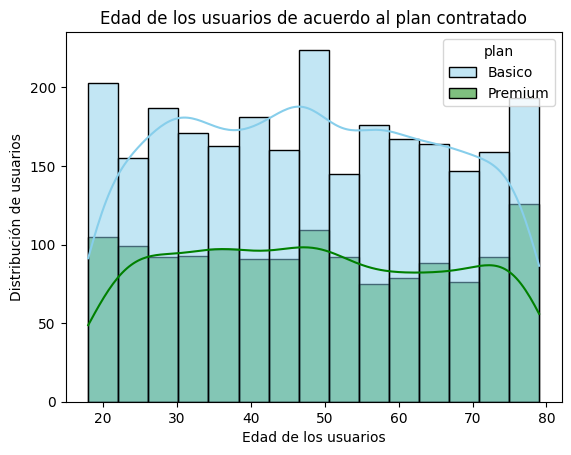

In [32]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x='age', hue='plan', bins=15, palette=['skyblue','green'], kde=True)
plt.xlabel('Edad de los usuarios')
plt.ylabel('Distribución de usuarios')
plt.title('Edad de los usuarios de acuerdo al plan contratado')
plt.show()


💡Insights: 
- Distribución homogenea, simetrica. Si bien el plan basico ocupa un 65 % de los clientes, el comportamiento del tipo de plan es indistinto de la edad, sin observaciones importantes.


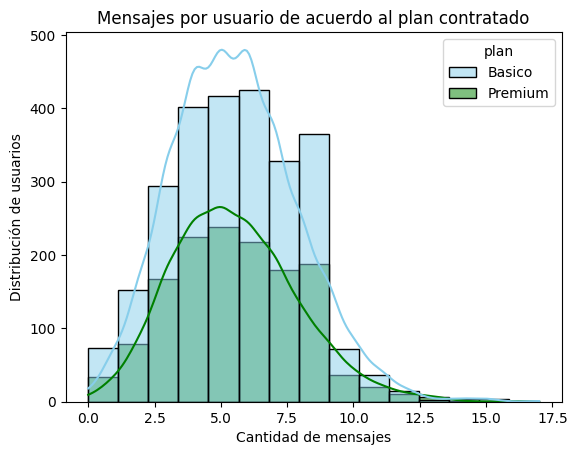

In [33]:
# Histograma para visualizar la cant_mensajes

sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', bins=15, palette=['skyblue','green'], kde=True)
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Distribución de usuarios')
plt.title('Mensajes por usuario de acuerdo al plan contratado')
plt.show()


💡Insights: 
- Con sesgo ligero a la derecha, la cantidad de mensajes es notario en ambos con planes con una mediana de 5.5

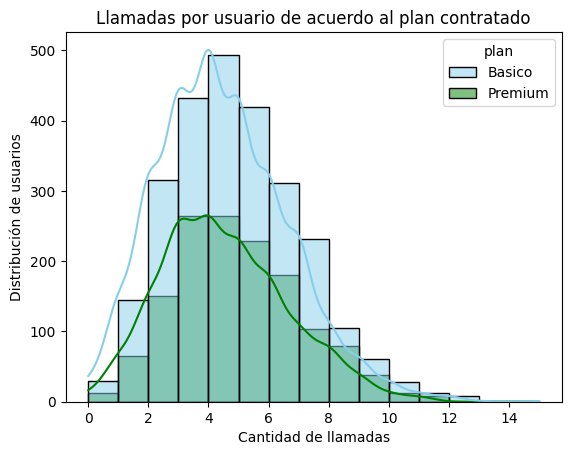

In [34]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', bins=15, palette=['skyblue','green'], kde=True)
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Distribución de usuarios')
plt.title('Llamadas por usuario de acuerdo al plan contratado')
plt.show()


💡Insights: 
- Distribución sutilmente sesgada a la derecha para ambos planes, notese un patron de promedio de 4.4 de cantidad de llamadas.

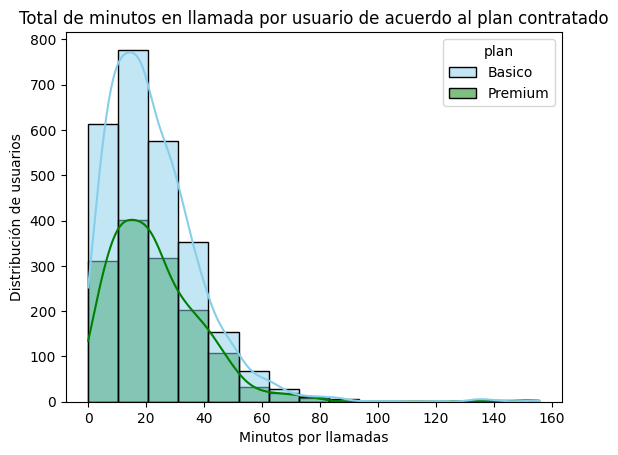

In [35]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', bins=15, palette=['skyblue','green'], kde=True)
plt.xlabel('Minutos por llamadas')
plt.ylabel('Distribución de usuarios')
plt.title('Total de minutos en llamada por usuario de acuerdo al plan contratado')
plt.show()


💡Insights: 
- Notese que ambos planes se estima un promedio de 20 minutos.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

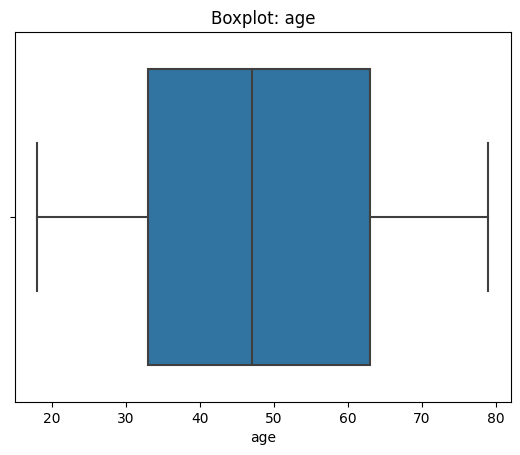

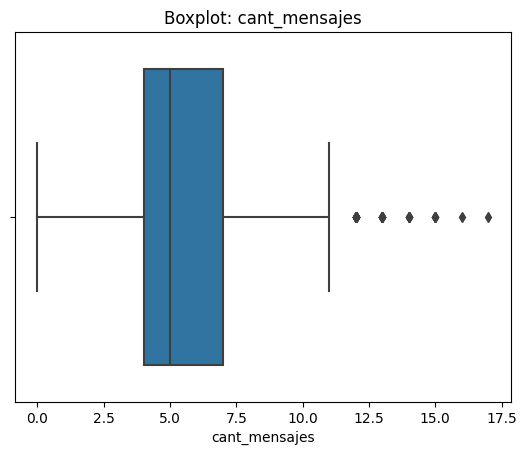

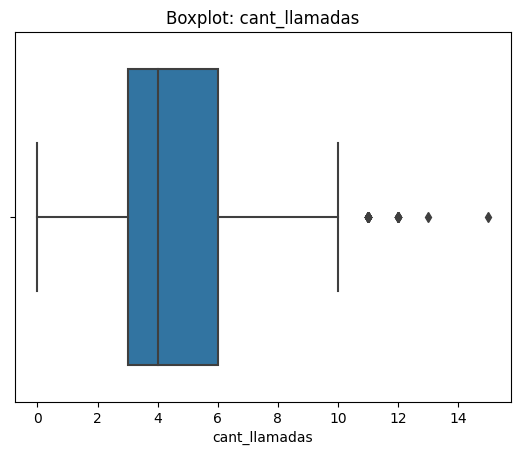

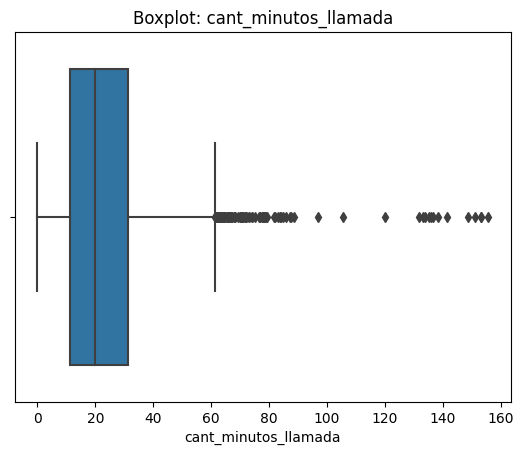

In [36]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
for col in columnas_numericas:
    
    sns.boxplot(data=user_profile, x=col)   
    plt.title(f'Boxplot: {col}')
    plt.show()


💡Insights: 
- Age: boxplot con datos estables, sin outliers.
- cant_mensajes: el valor atipico mayor es de 17 cantidad de mensajes, no requiere limpieza o revisión adicional.
- cant_llamadas: el valor atipico mayor es de 15 cantidad de llamadas, no requiere limpieza o revisión adicional.
- cant_minutos_llamada: bigote derecho mayor al contrario, el valor atipico mayor es de 115.7 cantidad de minutos en llamadas, no requiere limpieza o revisión adicional.

Límite inferior:  -0.5
Límite superior:  11.5


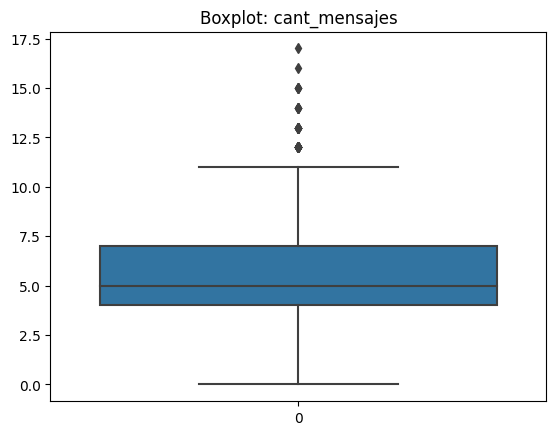

Límite inferior:  -1.5
Límite superior:  10.5


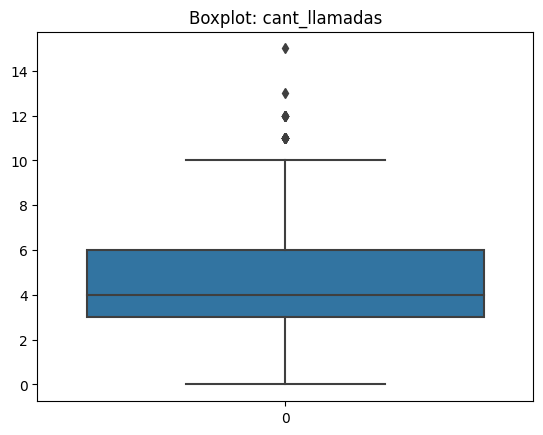

Límite inferior:  -19.04
Límite superior:  61.31999999999999


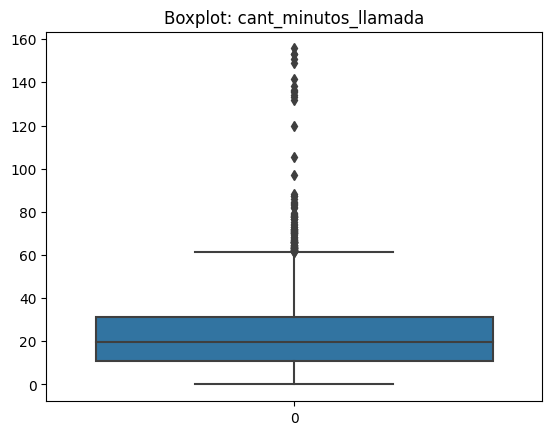

In [37]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    print('Límite inferior: ', lower)
    upper = Q3 + 1.5 * IQR
    print('Límite superior: ', upper)
    
    sns.boxplot(data=user_profile[col])
    plt.title(f'Boxplot: {col}')
    plt.show()


In [38]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,22.836934
std,2.358416,2.144238,16.590213
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.095000
50%,5.000000,4.000000,19.740000
75%,7.000000,6.000000,31.185000
max,17.000000,15.000000,155.690000


💡Insights: 

- cant_mensajes: mantener o no outliers, porqué?
- Límite superior:  11.5, max	17.0, la diferencia no es radical, se trata de un extremo real y es necesario mantener el dato.	
- cant_llamadas: mantener o no outliers, porqué?
- Límite superior:  10.5, max	15.0, la diferencia no es radical, se trata de un extremo real y es necesario mantener el dato.		
- cant_minutos_llamada: mantener o no outliers, porqué?
- Límite superior:  61.31, max 155.69, la diferencia no es radical, se trata de un extremo real y es necesario mantener el dato.
	

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [39]:
# Crear columna grupo_uso
def grupo_uso(row):
    llamadas = row['cant_llamadas']
    mensajes = row['cant_mensajes']

    if llamadas < 5 and mensajes < 5:
        return 'Bajo uso'
    elif llamadas < 10 and mensajes < 10:
        return 'Uso medio'
    else:
        return 'Alto uso'

user_profile['grupo_uso'] = user_profile.apply(grupo_uso, axis=1)

In [40]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [41]:
# Crear columna grupo_edad
def grupo_edad(row):
    edad = row['age']
   
    if edad < 30:
        return 'Joven'
    elif edad < 60:
        return 'Adulto'
    else:
        return 'Adulto Mayor'

user_profile['grupo_edad'] = user_profile.apply(grupo_edad, axis=1)


In [42]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


In [45]:
cols_uso_edad = ['grupo_uso', 'grupo_edad']

for col in cols_uso_edad:
    print(f'\nPorcentajes para {col}:')
    porcentajes = (
        user_profile[col]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
    )
    print(porcentajes)


Porcentajes para grupo_uso:
Uso medio    73.58
Bajo uso     19.45
Alto uso      6.98
Name: grupo_uso, dtype: float64

Porcentajes para grupo_edad:
Adulto          50.45
Adulto Mayor    30.55
Joven           19.00
Name: grupo_edad, dtype: float64


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

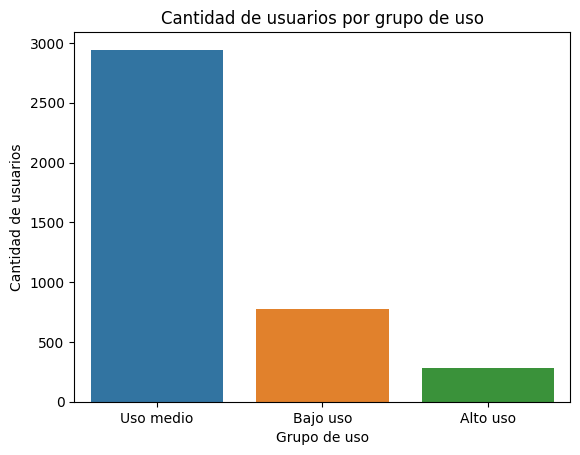

In [46]:
# Visualización de los segmentos por uso
sns.countplot(
    data=user_profile,
    x='grupo_uso',
    order=user_profile['grupo_uso'].value_counts().index
)

plt.title('Cantidad de usuarios por grupo de uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Cantidad de usuarios')
plt.show()


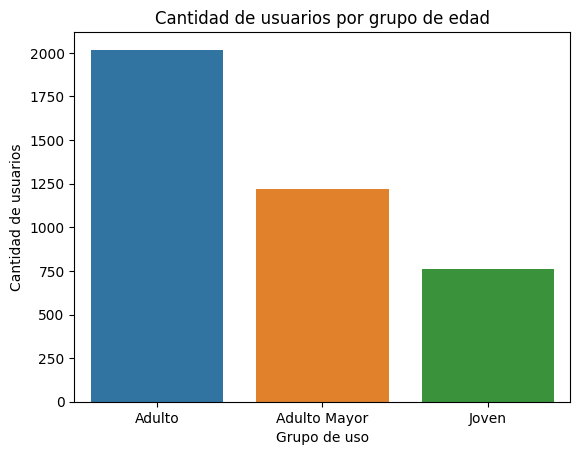

In [47]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad') 
plt.title('Cantidad de usuarios por grupo de edad') 
plt.xlabel('Grupo de uso') 
plt.ylabel('Cantidad de usuarios') 
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?

En el dataset 'plans' se encontró la información completa.
En el dataset 'users' se encontró 88 % de datos faltantes de la columna 'churn_date', en 'age' sentinels tipo -999 que se sustituyeron por la mediana, en 'city' sentinels de tipo '?' imputados por 'NA' y, finalmente, la columna 'reg_date' fue estadarizada a fecha.
En el dataset 'usage', se hallaron missingness en las columnas 'duration' y 'lenght', sin embargo, se demostró que eran valores tipo MAR y no se modificaron. La columna 'date' fue estadarizada a fecha.

- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?

El 'Uso medio' (llamadas < 10 y mensajes < 10) predomina en un 73.58 %, siendo el 'Alto uso' (llamadas > 10 y mensajes > 10), 6.98 % el que menos destaca.
Son el grupo de 'Adulto' (edad 30 a 60) los que mayormente utilizan el servicio con un  50.45 % y el grupo 'Joven' (edad < 30) en menor proporción, 19.00 %.


- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?
Grupo de 'Adulto' (edad 30 a 60) 50.45 %  y 'Uso medio' (llamadas < 10 y mensajes < 10), 73.58 % son los segmentos más destacados.
   
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?
- cant_mensajes: max	17.0, 
- cant_llamadas: max	15.0, 
- cant_minutos_llamada: max 155.69.
- Se consideran outliers reales, y es necesario observarlos, ya que podrían tratarse de clientes potenciales.

- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?
(1) Diseñar un plan Premium para usuarios de alto uso, maximizar ingresos provenientes de usuarios de alto consumo.
(2) Personalizar planes según edad:
Adultos mayores: Planes simples y económicos, atención preferencial, comunicación clara y sin cargos ocultos.
Jóvenes: mayor énfasis en servicios digitales. Promociones y descuentos temporales, beneficios relacionados con aplicaciones y redes sociales.

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- En el dataset 'plans' se encontró la información completa.
- En el dataset 'users' se encontró 88 % de datos faltantes de la columna 'churn_date', en 'age' sentinels tipo -999 que se sustituyeron por la mediana, en 'city' sentinels de tipo '?' imputados por 'NA' y, finalmente, la columna 'reg_date' fue estadarizada a fecha.
- En el dataset 'usage', se hallaron missingness en las columnas 'duration' y 'lenght', sin embargo, se demostró que eran valores tipo MAR y no se modificaron. La columna 'date' fue estadarizada a fecha.

🔍 **Segmentos por Edad**
- Porcentajes para grupo_edad:
Adulto (edad 30 a 60), 50.45 %
Adulto Mayor  (edad > 60)  30.55 %
Joven  (edad < 30), 19.00 %.

📊 **Segmentos por Nivel de Uso**
- Porcentajes para grupo_uso:
Uso medio (llamadas < 10 y mensajes < 10),   73.58 %.
Bajo uso  (llamadas < 5 y mensajes < 5),   19.45 %
Alto uso  (llamadas > 10 y mensajes > 10),    6.98 %.

➡️ Esto sugiere que:
(a) Los adultos representan la mayoría de los usuarios: cualquier mejora o promoción dirigida a este grupo tendrá un impacto significativo en los ingresos.
(b) Predomina el uso medio: esto indica que la mayoría utiliza los servicios de manera regular, pero sin llegar a niveles intensivos.

💡 **Recomendaciones**
(a) Crear un plan "Básico" para usuarios de bajo uso.
(b) Optimizar el plan para usuarios de uso medio.
(c) Diseñar un plan Premium para usuarios de alto uso
(d) Personalizar planes según edad.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`